In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [3]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

nav.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [4]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [5]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [6]:
results = []

for fund, grp in nav.groupby("amfi_code"):

    returns = grp["daily_return"].dropna()

    if len(returns) < 50:
        continue

    var95 = returns.quantile(0.05)

    cvar95 = returns[
        returns <= var95
    ].mean()

    results.append([
        fund,
        var95,
        cvar95
    ])

In [7]:
var_df = pd.DataFrame(
    results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [8]:
var_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("Report Saved")

Report Saved


In [9]:
import os

os.listdir("../reports")

['alpha_beta.csv',
 'aum_growth.png',
 'benchmark_comparison.png',
 'category_heatmap.png',
 'folio_growth.html',
 'fund_metrics.csv',
 'fund_scorecard.csv',
 'gender_distribution.html',
 'investor_age_distribution.html',
 'nav_correlation_heatmap.png',
 'nav_trend_analysis.html',
 'sector_allocation.html',
 'sip_amount_by_age.png',
 'sip_trend.html',
 'state_wise_sip.png',
 't30_b30_distribution.html',
 'var_cvar_report.csv']

In [10]:
var_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [11]:
len(var_df)

40

In [12]:
nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


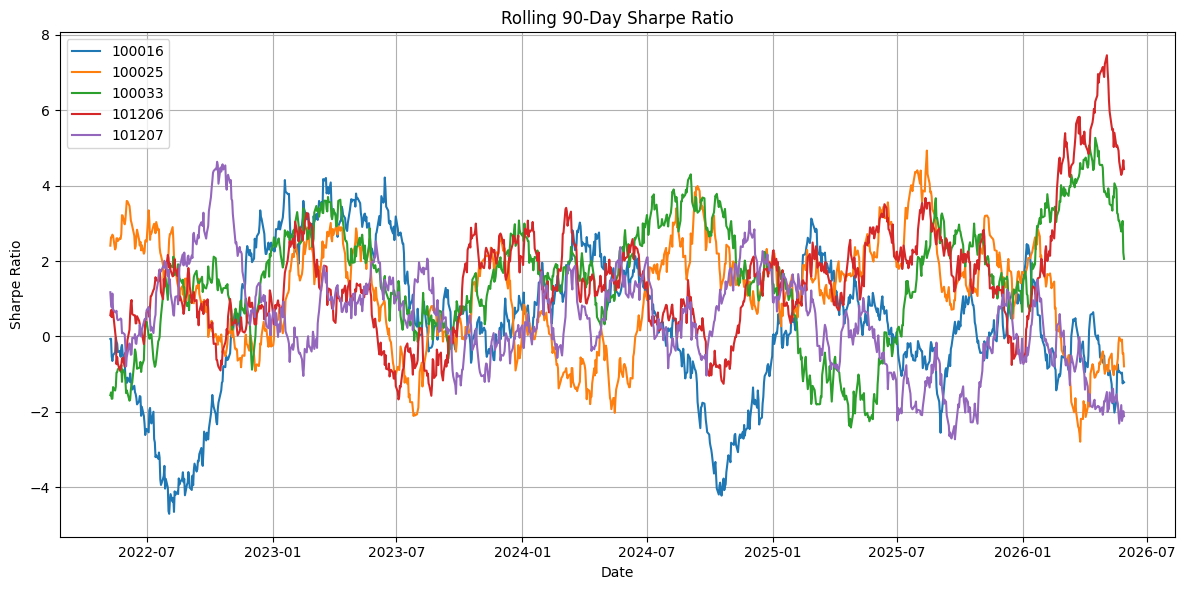

In [13]:
plt.figure(figsize=(12,6))

key_funds = nav["amfi_code"].unique()[:5]

for fund in key_funds:

    temp = nav[
        nav["amfi_code"] == fund
    ].copy()

    rolling_sharpe = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        temp["date"],
        rolling_sharpe,
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")

plt.xlabel("Date")

plt.ylabel("Sharpe Ratio")

plt.legend()

plt.grid(True)

plt.tight_layout()

In [14]:
plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

print("Chart Saved")

Chart Saved


<Figure size 640x480 with 0 Axes>

In [15]:
import os

os.listdir("../reports")

['alpha_beta.csv',
 'aum_growth.png',
 'benchmark_comparison.png',
 'category_heatmap.png',
 'folio_growth.html',
 'fund_metrics.csv',
 'fund_scorecard.csv',
 'gender_distribution.html',
 'investor_age_distribution.html',
 'nav_correlation_heatmap.png',
 'nav_trend_analysis.html',
 'rolling_sharpe_chart.png',
 'sector_allocation.html',
 'sip_amount_by_age.png',
 'sip_trend.html',
 'state_wise_sip.png',
 't30_b30_distribution.html',
 'var_cvar_report.csv']

In [16]:
investor = pd.read_csv(
    "../data/processed/investor_transactions_clean.csv"
)

investor.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [17]:
investor.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [18]:
investor['transaction_date'] = pd.to_datetime(
    investor['transaction_date']
)

investor['cohort_year'] = (
    investor.groupby('investor_id')['transaction_date']
    .transform('min')
    .dt.year
)

investor[['investor_id','cohort_year']].head()

,investor_id,cohort_year
0,INV003054,2024
1,INV002952,2024
2,INV003420,2024
3,INV003436,2024
4,INV004691,2024


In [19]:
cohort_analysis = (
    investor.groupby('cohort_year')
    .agg(
        avg_sip_amount=('amount_inr','mean'),
        total_invested=('amount_inr','sum'),
        investors=('investor_id','nunique')
    )
    .reset_index()
)

cohort_analysis

,cohort_year,avg_sip_amount,total_invested,investors
0,2024,107422.541832,3491125187,4803
1,2025,109158.577061,30455243,197


In [20]:
top_funds = (
    investor.groupby(
        ['cohort_year','amfi_code']
    )
    .size()
    .reset_index(name='count')
)

top_funds = (
    top_funds.sort_values(
        ['cohort_year','count'],
        ascending=False
    )
    .groupby('cohort_year')
    .head(1)
)

top_funds

,cohort_year,amfi_code,count
62,2025,119599,12
35,2024,148568,874


In [21]:
sip = investor[
    investor['transaction_type']
    .str.lower() == 'sip'
].copy()

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,Sip,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,Sip,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [22]:
sip = sip.sort_values(
    ['investor_id','transaction_date']
)

In [23]:
sip['gap_days'] = (
    sip.groupby('investor_id')
       ['transaction_date']
       .diff()
       .dt.days
)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,Sip,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,Sip,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,Sip,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,Sip,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,Sip,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0


In [24]:
sip_counts = (
    sip.groupby('investor_id')
       .size()
)

eligible = sip_counts[
    sip_counts >= 6
].index

sip_eligible = sip[
    sip['investor_id'].isin(eligible)
]

len(eligible)

1362

In [25]:
continuity = (
    sip_eligible.groupby('investor_id')
    .agg(
        avg_gap_days=('gap_days','mean')
    )
    .reset_index()
)

continuity['status'] = np.where(
    continuity['avg_gap_days'] > 35,
    'At Risk',
    'Active'
)

continuity.head()

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [26]:
continuity['status'].value_counts()

status
At Risk    1332
Active       30
Name: count, dtype: int64

In [27]:
funds = pd.read_csv(
    "../data/processed/scheme_performance_clean.csv"
)

funds.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [28]:
funds['risk_grade'].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [29]:
def recommend_funds(risk_appetite):

    risk_map = {
        'Low': ['Low'],
        'Moderate': ['Moderate', 'Moderately High'],
        'High': ['High', 'Very High']
    }

    selected = funds[
        funds['risk_grade'].isin(
            risk_map[risk_appetite]
        )
    ]

    recommendations = (
        selected
        .sort_values(
            'sharpe_ratio',
            ascending=False
        )
        .head(3)
    )

    return recommendations[
        [
            'amfi_code',
            'risk_grade',
            'sharpe_ratio',
            'return_3yr_pct'
        ]
    ]

In [30]:
recommend_funds('Moderate')

,amfi_code,risk_grade,sharpe_ratio,return_3yr_pct
5,100016,Moderate,1.06,14.84
34,148567,Moderate,1.06,14.81
11,120504,Moderate,1.03,14.41


In [31]:
holdings = pd.read_csv(
    "../data/processed/portfolio_holdings_clean.csv"
)

holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [32]:
hhi = (
    holdings.groupby("amfi_code")["weight_pct"]
    .apply(lambda x: ((x / 100) ** 2).sum())
    .reset_index()
)

hhi.columns = ["amfi_code", "HHI"]

hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [33]:
hhi.sort_values(
    "HHI",
    ascending=False
).head(10)

,amfi_code,HHI
11,119092,0.206448
3,101207,0.200700
18,119599,0.174751
4,102885,0.174709
7,118632,0.168298
29,148568,0.167930
21,120505,0.157570
22,120506,0.153794
27,125498,0.152414
23,120841,0.149680


In [34]:
hhi.sort_values(
    "HHI",
    ascending=True
).head(10)

,amfi_code,HHI
17,119598,0.107349
16,119552,0.108011
9,118634,0.108358
20,120504,0.108674
14,119095,0.109605
5,102886,0.114693
33,149324,0.118677
15,119551,0.118716
8,118633,0.121461
24,120842,0.127439


## Advanced Analytics Insights

### Insight 1
Funds with the highest VaR and CVaR values exhibited significantly greater downside risk, indicating larger potential losses during adverse market conditions.

### Insight 2
Rolling 90-Day Sharpe Ratios fluctuated across market cycles, highlighting periods of strong and weak risk-adjusted performance.

### Insight 3
Recent investor cohorts demonstrated higher average investment amounts and greater participation compared to earlier cohorts.

### Insight 4
SIP continuity analysis identified a large number of investors with average transaction gaps exceeding 35 days, suggesting potential SIP discontinuation risk.

### Insight 5
Funds with lower HHI values maintained better portfolio diversification, while high-HHI funds showed greater concentration in a limited number of holdings.